**Set environment**

In [1]:
suppressMessages(suppressWarnings(source("../run_config_project.R")))
show_env()

BASE DIRECTORY (FD_BASE): /hpc/group/igvf/kk319 
REPO DIRECTORY (FD_REPO): /hpc/group/igvf/kk319/repo 
WORK DIRECTORY (FD_WORK): /hpc/group/igvf/kk319/work 
DATA DIRECTORY (FD_DATA): /hpc/group/igvf/kk319/data 

You are working with      IGVF BlueSTARR 
PATH OF PROJECT (FD_PRJ): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR 
PROJECT RESULTS (FD_RES): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/results 
PROJECT SCRIPTS (FD_EXE): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/scripts 
PROJECT DATA    (FD_DAT): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/data 
PROJECT NOTE    (FD_NBK): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/notebooks 
PROJECT DOCS    (FD_DOC): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/docs 
PROJECT LOG     (FD_LOG): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/log 
PROJECT REF     (FD_REF): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/references 



## Import data

**Check file existence**

In [2]:
### set file directory
txt_fdiry = file.path(FD_RES, "analysis_variant_motif_richard")
txt_fname = "variant_closed_gof_bluestarr*"
txt_fglob = file.path(txt_fdiry, txt_fname)

vec = Sys.glob(txt_fglob)
vec = basename(vec)
for (txt in vec){cat(txt, "\n")}

variant_closed_gof_bluestarr.flankL35R70.unobs_vs_obs.ref.fa 
variant_closed_gof_bluestarr.tsv 


**Import table**

In [3]:
### set file directory
txt_fdiry = file.path(FD_RES, "analysis_variant_motif_richard")
txt_fname = "variant_closed_gof_bluestarr.tsv"
txt_fpath = file.path(txt_fdiry, txt_fname)

### read table
dat = read_tsv(txt_fpath, show_col_types = FALSE)

### assign and show
dat_variant_bluestarr_import = dat
print(dim(dat))
fun_display_table(head(dat, 3))

[1] 1885038      14


Chrom,ChromStart,ChromEnd,Region,Variant_ID,Pos0,Rank4,Rank3,Rank2,Rank1,Ref,Obs,Unobs,Delta
chr2,234143174,234143434,chr2:234143174-234143434,chr2:234143291:C,234143291,C,T,A,G,C,C,G,1.708901
chr6,111030999,111031188,chr6:111030999-111031188,chr6:111031101:A,111031101,G,A,T,C,A,G,C,1.625281
chr5,73091238,73091414,chr5:73091238-73091414,chr5:73091405:T,73091405,C,T,G,A,T,C,A,1.597880


## Explore

### Summarize the Delta

In [4]:
dat = dat_variant_bluestarr_import
summary(dat$Delta)

     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
0.0001396 0.0147048 0.0234016 0.0304745 0.0366673 1.7089007 

### Histogram of Delta

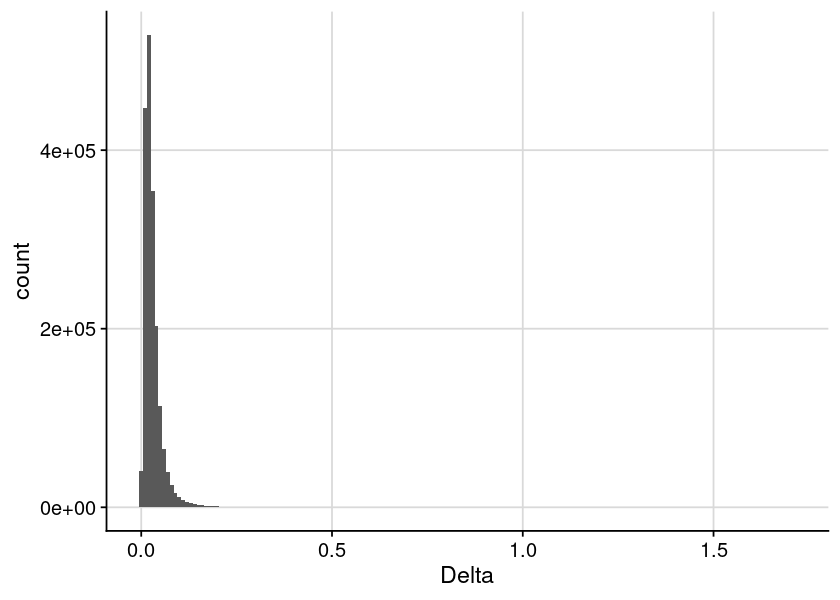

In [5]:
dat = dat_variant_bluestarr_import
gpt = ggplot(dat, aes(x = Delta)) + 
    geom_histogram(binwidth = 0.01) + 
    theme_cowplot() +
    background_grid()

options(repr.plot.height=5, repr.plot.width=7)
print(gpt)

**Set exported plot**

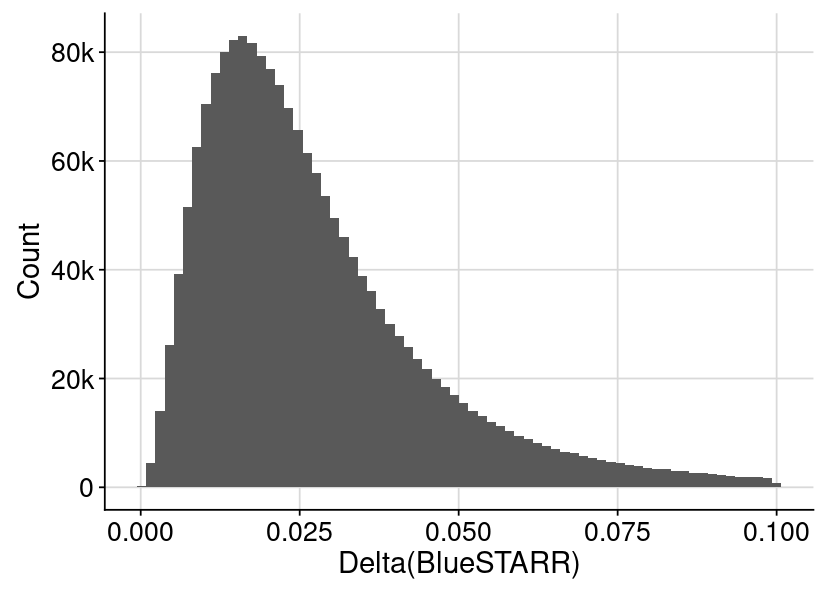

In [6]:
fun_label_km <- function(x) {
  sapply(x, function(v) {
    if (is.na(v)) return(NA_character_)
    if (v < 1e3) return(as.character(v))        # 0, 500, etc.
    if (v < 1e6) return(paste0(round(v / 1e3), "k"))
    paste0(format(round(v / 1e6, 1), trim = TRUE), "M")
  })
}

dat = dat_variant_bluestarr_import
dat = dat %>% dplyr::filter(Delta < 0.1)

gpt = ggplot(dat, aes(x = Delta)) + 
    geom_histogram(bins = 70) + 
    theme_pub(base_size = 16) +
    scale_y_continuous(
        labels = fun_label_km,
        breaks = scales::pretty_breaks(5)
    ) +
    labs(x = "Delta(BlueSTARR)", y = "Count")

gpt_export_histogram = gpt
options(repr.plot.height=5, repr.plot.width=7)
print(gpt)

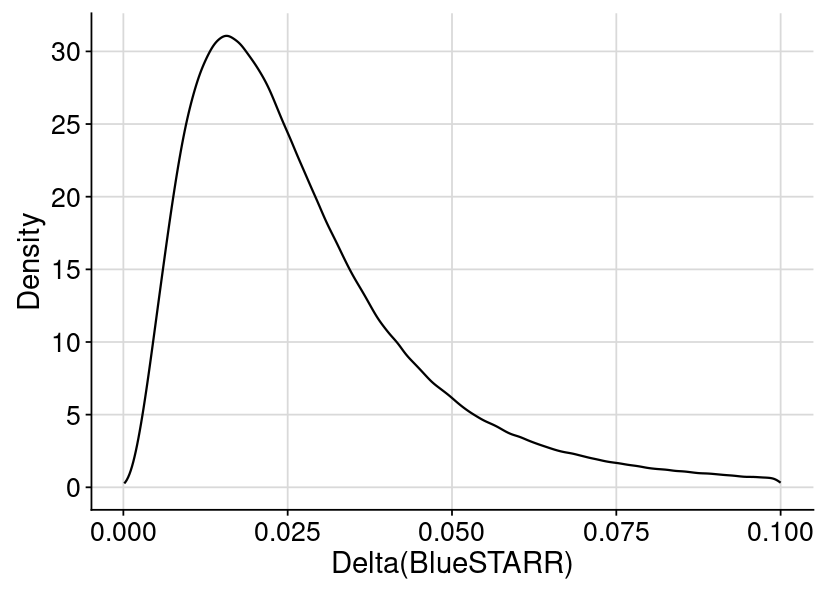

In [7]:
dat = dat_variant_bluestarr_import
dat = dat %>% dplyr::filter(Delta < 0.1)

gpt = ggplot(dat, aes(x = Delta)) + 
    geom_density() + 
    theme_pub(base_size = 16) +
    scale_y_continuous(
        #labels = fun_label_km,
        breaks = scales::pretty_breaks(5)
    ) +
    labs(x = "Delta(BlueSTARR)", y = "Density")

gpt_export_density = gpt
options(repr.plot.height=5, repr.plot.width=7)
print(gpt)

### Delta in descending order

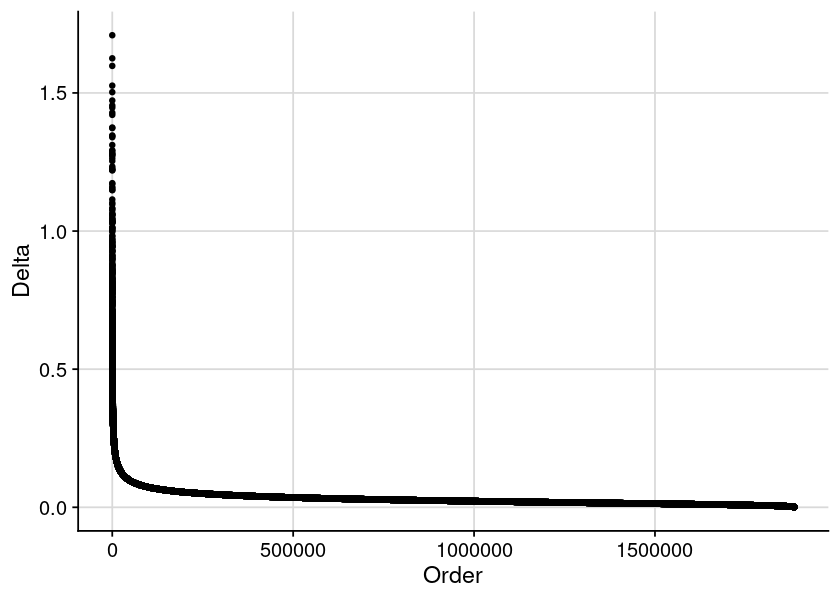

In [8]:
dat = dat_variant_bluestarr_import
dat = dat %>% dplyr::mutate(Order = row_number())

gpt = ggplot(dat, aes(x = Order, y = Delta)) + 
    geom_point(size = 1) + 
    theme_cowplot() +
    background_grid()

options(repr.plot.height=5, repr.plot.width=7)
print(gpt)

**Set exported plot**

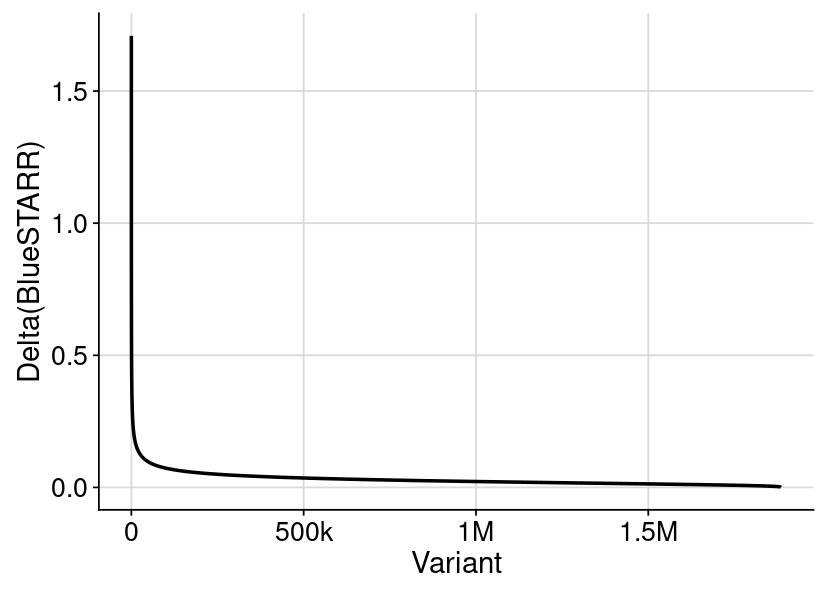

In [9]:
dat = dat_variant_bluestarr_import
dat = dat %>% dplyr::mutate(Order = row_number())

num_keep = 50000
num_step = 1000 

dat = bind_rows(
    dat %>% slice(1:num_keep),
    dat %>% slice(seq(num_keep + 1, n(), by = num_step))
)

fun_label_km <- function(x) {
  sapply(x, function(v) {
    if (is.na(v)) return(NA_character_)
    if (v < 1e3) return(as.character(v))        # 0, 500, etc.
    if (v < 1e6) return(paste0(round(v / 1e3), "k"))
    paste0(format(round(v / 1e6, 1), trim = TRUE), "M")
  })
}

gpt = ggplot(dat, aes(x = Order, y = Delta)) + 
    geom_line(linewidth = 1) + 
    theme_pub(base_size = 16) +
    scale_x_continuous(
        labels = fun_label_km,
        breaks = scales::pretty_breaks(5)
    ) +
    labs(x = "Variant", y = "Delta(BlueSTARR)")

gpt_export_order_line = gpt
options(repr.plot.height=5, repr.plot.width=7)
print(gpt)

## Justify top/low 100k variants is enough for downstream analysis

In [10]:
num_cut = 1e5

dat = dat_variant_bluestarr_import 
dat = dat %>% dplyr::arrange(desc(Delta))
dat = tibble(
    Top_variants           = num_cut,
    Fraction_Total_Delta   = sum(dat$Delta[1:num_cut]) / sum(dat$Delta),
    Max_Delta_Remaining    = max(dat$Delta[-(1:num_cut)]),
    Median_Delta_Remaining = median(dat$Delta[-(1:num_cut)])
)

fun_display_table(dat)

Top_variants,Fraction_Total_Delta,Max_Delta_Remaining,Median_Delta_Remaining
1e+05,0.2061721,0.0727359,0.0223798


### Summarize top 100k variants and the remaining variants

The top 100k variants capture the full Δ dynamic range, while remaining variants are uniformly low-effect.

Across all variants, Delta(BlueSTARR) values range from 0 to 0.96. The top 100k variants include the full observed Δ range (max Δ = 0.96), whereas variants outside this set are restricted to much smaller effect sizes (maximum Δ ≈ 0.024; median Δ ≈ 0.005), indicating that the remaining variants are having a narrow low effect.

In [11]:
num_cut = 1e5

dat = dat_variant_bluestarr_import 
dat = dat %>% dplyr::arrange(desc(Delta))
dat = tibble(
    Max_delta_total   = max(dat$Delta),
    Max_Delta_top100k = max(dat$Delta[1:num_cut]),
    Min_Delta_top100k = min(dat$Delta[1:num_cut]),
    Max_Delta_Remaining    = max(dat$Delta[-(1:num_cut)]),
    Median_Delta_Remaining = median(dat$Delta[-(1:num_cut)])
)

fun_display_table(dat)

Max_delta_total,Max_Delta_top100k,Min_Delta_top100k,Max_Delta_Remaining,Median_Delta_Remaining
1.708901,1.708901,0.0727361,0.0727359,0.0223798


In [12]:
num_cut = 1e5

dat = dat_variant_bluestarr_import 
dat = dat %>% dplyr::arrange(Delta)
dat = tibble(
    Max_delta_total   = max(dat$Delta),
    Max_Delta_low100k = max(dat$Delta[1:num_cut]),
    Min_Delta_low100k = min(dat$Delta[1:num_cut]),
    Max_Delta_Remaining    = max(dat$Delta[-(1:num_cut)]),
    Median_Delta_Remaining = median(dat$Delta[-(1:num_cut)])
)

fun_display_table(dat)

Max_delta_total,Max_Delta_low100k,Min_Delta_low100k,Max_Delta_Remaining,Median_Delta_Remaining
1.708901,0.0071373,0.0001396,1.708901,0.0244655


### Rank-ordered distribution of Delta values in log scale
The dashed vertical line marks the modeling cutoff at 100k variants. After 100k, the curve flattens, showing that most additional variants have progressively smaller effects.

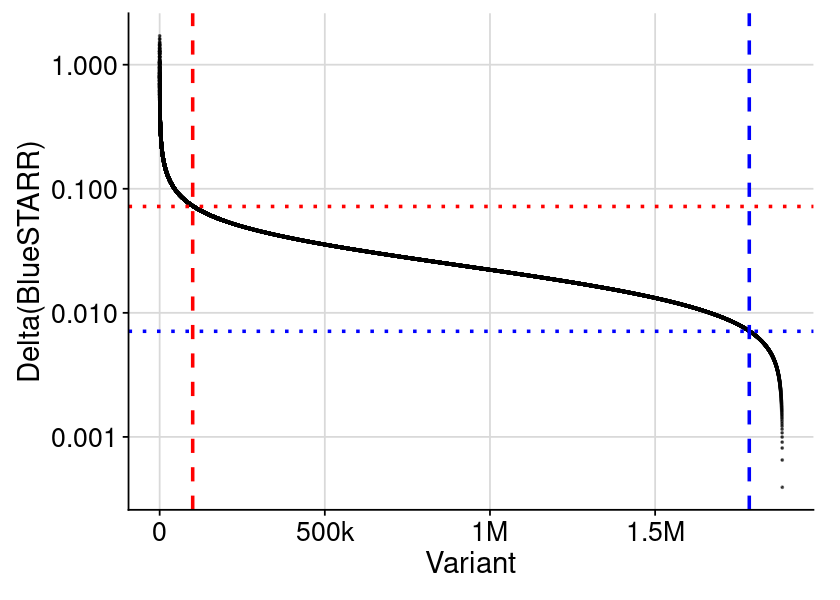

In [13]:
num_keep  = 200000 # dense tail
num_step  = 100    # aggressive downsample
num_cut   = 1e5    # top/bottom 100k = 100,000 = 1e5
num_total = nrow(dat_variant_bluestarr_import)
num_end   = num_total - num_cut

dat = dat_variant_bluestarr_import
dat = dat %>%
    dplyr::filter(Delta > 0) %>%
    dplyr::arrange(desc(Delta)) %>%
    dplyr::mutate(Rank = row_number())

dat = bind_rows(
    dat %>% dplyr::slice(1:num_keep),
    dat %>% dplyr::slice(seq(num_keep + 1, n(), by = num_step))
)

num_delta = max(dat$Delta[dat$Rank > num_cut])

gpt = ggplot(dat, aes(Rank, Delta)) +
    geom_point(size = 0.2, alpha = 0.6) +
    geom_vline(xintercept = num_cut, linewidth=1.0, linetype = "dashed", color = "red")  +
    geom_vline(xintercept = num_end, linewidth=1.0, linetype = "dashed", color = "blue") +
    geom_hline(yintercept = 0.072,  linewidth=1.0, linetype = "dotted", color = "red") +
    geom_hline(yintercept = 0.0071, linewidth=1.0, linetype = "dotted", color = "blue") +
    scale_y_log10() +
    scale_x_continuous(labels = fun_label_km) +
    theme_pub(base_size = 16) +
    labs(x = "Variant", y = "Delta(BlueSTARR)")

gpt_export_order_logscale = gpt
options(repr.plot.height=5, repr.plot.width=7)
print(gpt)

### Quantile analysis
Between 100k and 200k variants, the median Delta decreases from 0.030 to 0.024 and the 95th percentile decreases from 0.066 to 0.052, indicating limited additional coverage of higher-effect relative to the increase in data volume.

In [14]:
dat = dat_variant_bluestarr_import
print(dim(dat))
fun_display_table(head(dat, 3))

[1] 1885038      14


Chrom,ChromStart,ChromEnd,Region,Variant_ID,Pos0,Rank4,Rank3,Rank2,Rank1,Ref,Obs,Unobs,Delta
chr2,234143174,234143434,chr2:234143174-234143434,chr2:234143291:C,234143291,C,T,A,G,C,C,G,1.708901
chr6,111030999,111031188,chr6:111030999-111031188,chr6:111031101:A,111031101,G,A,T,C,A,G,C,1.625281
chr5,73091238,73091414,chr5:73091238-73091414,chr5:73091405:T,73091405,C,T,G,A,T,C,A,1.597880


In [15]:
quantiles = c(0.5, 0.75, 0.9, 0.95, 0.99)

cuts = c(1e4, 5e4, 1e5, 5e5, 1e6)
dat = dat_variant_bluestarr_import
lst = lapply(cuts, function(num) {
    qs  = quantile(dat$Delta[1:num], probs = quantiles)
    dat = tibble(
        CutOff = num,
        Q = quantiles,
        Delta = as.numeric(qs)
    )
    return(dat)
})

dat = bind_rows(lst)
dat = dat %>% 
    dplyr::mutate(Q = paste0("Q", as.character(Q * 100))) %>%
    tidyr::pivot_wider(names_from = Q, values_from  = Delta)

fun_display_table(dat)

CutOff,Q50,Q75,Q90,Q95,Q99
1e+04,0.2321552,0.3007701,0.4172576,0.5257656,0.8752474
5e+04,0.1264542,0.1648521,0.2321535,0.3007576,0.5257376
1e+05,0.0959882,0.1264540,0.1793297,0.2321533,0.4172555
5e+05,0.0496246,0.0664868,0.0959878,0.1264539,0.2321531
1e+06,0.0355280,0.0496246,0.0727359,0.0959878,0.1793264


## Export figures

In [16]:
fun_save_plot = function(plt_export, txt_prefix, num_height, num_width){
    formats = c("png", "pdf", "svg")
    for (fmt in formats){
        txt_fpath = paste0(txt_prefix, ".", fmt)
        if (fmt == "png") {
            ggsave(
                filename = txt_fpath,
                plot     = plt_export,
                width    = num_width,
                height   = num_height,
                dpi      = 300
            )
        } else {
            ggsave(
                filename = txt_fpath,
                plot     = plt_export,
                width    = num_width,
                height   = num_height
            )
        }
    }
}

In [17]:
plt_export = gpt_export_histogram
num_height = 5
num_width  = 7
txt_prefix = "./fig.delta_bluestarr.histogram"
fun_save_plot(plt_export, txt_prefix, num_height, num_width)

In [18]:
plt_export = gpt_export_density
num_height = 5
num_width  = 7
txt_prefix = "./fig.delta_bluestarr.density"
fun_save_plot(plt_export, txt_prefix, num_height, num_width)

In [19]:
plt_export = gpt_export_order_line
num_height = 5
num_width  = 7
txt_prefix = "./fig.delta_bluestarr.order.line"
fun_save_plot(plt_export, txt_prefix, num_height, num_width)

In [20]:
plt_export = gpt_export_order_logscale
num_height = 5
num_width  = 7
txt_prefix = "./fig.delta_bluestarr.order.logscale"
fun_save_plot(plt_export, txt_prefix, num_height, num_width)